In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras as K
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, PReLU, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.initializers import glorot_uniform
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.preprocessing import StandardScaler

gpus = tf.config.list_physical_devices('GPU')
print("GPUs:", gpus)

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("memory growth enabled")
    except RuntimeError as e:
        print(e)



loadPath = '/home/sz4544/EEG-motor-imagery-main/project/'

train_path = os.path.join(loadPath, 'train12720_raw_EEG.h5')
valid_path = os.path.join(loadPath, 'valid2544_raw_EEG.h5')
test_path  = os.path.join(loadPath, 'test2544_raw_EEG.h5')
synthetic_path = os.path.join(loadPath, 'cwgangp_synthetic_train_full.h5')

model_dir = os.path.join(loadPath, 'models')
os.makedirs(model_dir, exist_ok=True)

save_model_path = os.path.join(model_dir, 'cnn_full_cwgangp_aug.keras')

print(train_path)
print(valid_path)
print(test_path)
print(synthetic_path)
print(save_model_path)


f_train = h5py.File(train_path, 'r')
tr_data = f_train['data'][:]
ytr = f_train['tasks'][:]

f_valid = h5py.File(valid_path, 'r')
val_data = f_valid['data'][:]
yval = f_valid['tasks'][:]

f_test = h5py.File(test_path, 'r')
ts_data = f_test['data'][:]
yts = f_test['tasks'][:]

print("real train:", tr_data.shape, ytr.shape)
print("valid:", val_data.shape, yval.shape)
print("test:", ts_data.shape, yts.shape)

f_syn = h5py.File(synthetic_path, 'r')
syn_data = f_syn['data'][:]
syn_y = f_syn['tasks'][:]

print("synthetic:", syn_data.shape, syn_y.shape)
print("synthetic label counts:", np.bincount(syn_y))




ytr = ytr.astype(np.int32)
yval = yval.astype(np.int32)
yts = yts.astype(np.int32)
syn_y = syn_y.astype(np.int32)

if np.array_equal(np.unique(ytr), np.array([1, 2, 3, 4])):
    ytr = ytr - 1
if np.array_equal(np.unique(yval), np.array([1, 2, 3, 4])):
    yval = yval - 1
if np.array_equal(np.unique(yts), np.array([1, 2, 3, 4])):
    yts = yts - 1

print("train labels:", np.unique(ytr))
print("valid labels:", np.unique(yval))
print("test labels:", np.unique(yts))
print("synthetic labels:", np.unique(syn_y))
aug_tr_data = np.concatenate([tr_data, syn_data], axis=0)
aug_ytr = np.concatenate([ytr, syn_y], axis=0)

print("aug train data:", aug_tr_data.shape)
print("aug train labels:", aug_ytr.shape)
print("aug train label counts:", np.bincount(aug_ytr))


xtr_flat = np.squeeze(aug_tr_data).reshape((-1, 64))
xval_flat = np.squeeze(val_data).reshape((-1, 64))
xts_flat = np.squeeze(ts_data).reshape((-1, 64))

print(xtr_flat.shape)
print(xval_flat.shape)
print(xts_flat.shape)

scaler = StandardScaler()
Ztr_flat = scaler.fit_transform(xtr_flat)
Zval_flat = scaler.transform(xval_flat)
Zts_flat = scaler.transform(xts_flat)

Ztr = Ztr_flat.reshape((-1, 640, 64))
Zval = Zval_flat.reshape((-1, 640, 64))
Zts = Zts_flat.reshape((-1, 640, 64))

print(Ztr.shape)
print(Zval.shape)
print(Zts.shape)

x_train = Ztr[..., np.newaxis].astype(np.float32)
x_valid = Zval[..., np.newaxis].astype(np.float32)
x_test  = Zts[..., np.newaxis].astype(np.float32)

y_train = pd.get_dummies(aug_ytr).values.astype(np.float32)
y_valid = pd.get_dummies(yval).values.astype(np.float32)
y_test  = pd.get_dummies(yts).values.astype(np.float32)

print("x_train:", x_train.shape)
print("x_valid:", x_valid.shape)
print("x_test:", x_test.shape)

print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)
print("y_test:", y_test.shape)








I0000 00:00:1774017748.609249   11139 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
memory growth enabled
/home/sz4544/EEG-motor-imagery-main/project/train12720_raw_EEG.h5
/home/sz4544/EEG-motor-imagery-main/project/valid2544_raw_EEG.h5
/home/sz4544/EEG-motor-imagery-main/project/test2544_raw_EEG.h5
/home/sz4544/EEG-motor-imagery-main/project/cwgangp_synthetic_train_full.h5
/home/sz4544/EEG-motor-imagery-main/project/models/cnn_full_cwgangp_aug.keras
real train: (12720, 640, 64) (12720,)
valid: (2544, 640, 64) (2544,)
test: (2544, 640, 64) (2544,)
synthetic: (4000, 640, 64) (4000,)
synthetic label counts: [1000 1000 1000 1000]
train labels: [0 1 2 3]
valid labels: [0 1 2 3]
test labels: [0 1 2 3]
synthetic labels: [0 1 2 3]
aug train data: (16720, 640, 64)
aug train labels: (16720,)
aug train label counts: [4180 4180 4180 4180]
(10700800, 64)
(1628160, 64)
(1628160, 64)
(16720, 640, 64)
(2544, 640, 64)
(2544, 640, 64)
x_train: (16720, 640, 64, 1)
x_valid: (2544, 640, 64, 1)
x_test: (2544, 640, 64

I0000 00:00:1774017769.451823   11139 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22272 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:41:00.0, compute capability: 8.9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 640, 64, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 313, 56, 8)     │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 313, 56, 8)     │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu (PReLU)                 │ (None, 313, 56, 8)     │       140,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 156, 28, 8)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 71, 20, 16)     │        17,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 71, 20, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_1 (PReLU)               │ (None, 71, 20, 16)     │        22,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 22720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │       363,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,028 (2.08 MB)

 Trainable params: 544,980 (2.08 MB)

...

 45/523 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - categorical_accuracy: 0.2724 - loss: 1.4439

I0000 00:00:1774017779.035197   11299 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


510/523 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - categorical_accuracy: 0.2931 - loss: 1.3858

I0000 00:00:1774017781.196817   11295 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3022__.41


523/523 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - categorical_accuracy: 0.2934 - loss: 1.3854
Epoch 1: val_categorical_accuracy improved from None to 0.31014, saving model to /home/sz4544/EEG-motor-imagery-main/project/models/cnn_full_cwgangp_aug.keras
523/523 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - categorical_accuracy: 0.3031 - loss: 1.3694 - val_categorical_accuracy: 0.3101 - val_loss: 1.3496
Epoch 2/300
520/523 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - categorical_accuracy: 0.3609 - loss: 1.3241
Epoch 2: val_categorical_accuracy improved from 0.31014 to 0.37461, saving model to /home/sz4544/EEG-motor-imagery-main/project/models/cnn_full_cwgangp_aug.keras
523/523 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - categorical_accuracy: 0.3679 - loss: 1.3185 - val_categorical_accuracy: 0.3746 - val_loss: 1.3099
Epoch 3/300
520/523 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.4038 - loss: 1.2764
Epoch 3: val_categorical_accuracy did not improve from 0.37461
523/523 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - cat

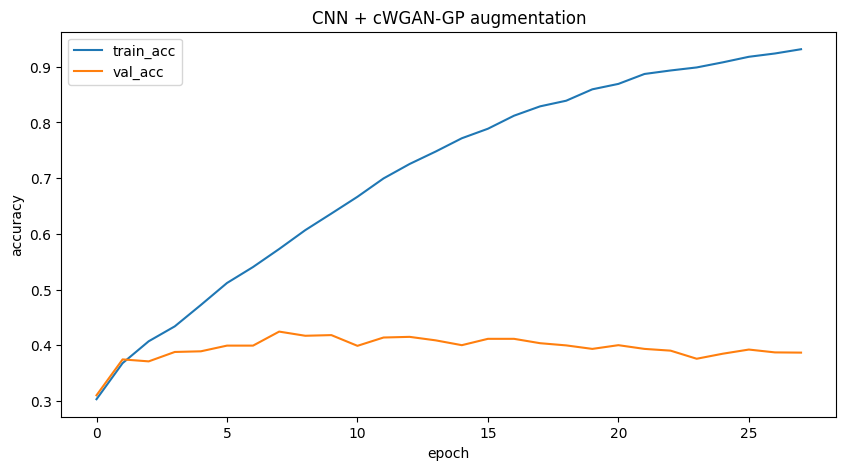

In [2]:
nodes = 640
inputs = Input(shape=(nodes, 64, 1))

conv1 = Conv2D(8, (15,9), strides=(2,1), kernel_initializer=glorot_uniform(seed=42))(inputs)
batch1 = BatchNormalization()(conv1)
prelu1 = PReLU()(batch1)
maxpool1 = MaxPooling2D((2,2))(prelu1)

conv2 = Conv2D(16, (15,9), strides=(2,1), kernel_initializer=glorot_uniform(seed=42))(maxpool1)
batch2 = BatchNormalization()(conv2)
prelu2 = PReLU()(batch2)

flat = Flatten()(prelu2)
dense1 = Dense(16, activation='sigmoid', kernel_initializer=glorot_uniform(seed=42))(flat)
drop1 = Dropout(0.2)(dense1)
predictions = Dense(4, activation='softmax', kernel_initializer=glorot_uniform(seed=42))(drop1)

model = Model(inputs=inputs, outputs=predictions)
print(model.summary())

opt_adam = K.optimizers.Adam(
    learning_rate=0.0001,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-08
)

model.compile(
    loss='categorical_crossentropy',
    optimizer=opt_adam,
    metrics=['categorical_accuracy']
)


es = EarlyStopping(
    monitor='val_categorical_accuracy',
    mode='max',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

mc = ModelCheckpoint(
    save_model_path,
    monitor='val_categorical_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

history = model.fit(
    x=x_train,
    y=y_train,
    epochs=300,
    batch_size=32,
    shuffle=True,
    verbose=1,
    validation_data=(x_valid, y_valid),
    callbacks=[es, mc]
)

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=1)
print("Final test loss:", test_loss)
print("Final test accuracy:", test_acc)

plt.figure(figsize=(10,5))
plt.plot(history.history['categorical_accuracy'], label='train_acc')
plt.plot(history.history['val_categorical_accuracy'], label='val_acc')
plt.legend()
plt.title('CNN + cWGAN-GP augmentation')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

